# Syriac pretraining: crops, GT, and Calamari predictions

Val CER on `lstm_layers_3/final/best.pt` is **28.7%**, stuck because two length bins are terrible:

| GT length | samples | chars | CER |
|---|---|---|---|
| 1–7 | 52 | 165 | **64.2%** |
| 8–28 (almost all 2025) | 1453 | 26.6k | **17.3%** |
| 29–62 (almost all 2024) | 290 | 13.6k | **50.5%** |

That is not a capacity problem. **2025 is 17.5% CER. 2024 is 50.7% CER.** 2024 is 16% of val lines but **34% of val characters and 60% of all character errors.** The 29–62 bin *is* the 2024 corpus. The 1–7 bin is folio numbers, abbreviation marks, and sideways crops.

The charset contains Latin `v`/`V`/`s`, digits `0–9`, ASCII `.` `:`, `,`, Arabic tatweel, and ZWNJ because those strings are in the GT.

In [ ]:

#! in syriac cer might be biased isnce two sample of same is used need to look into this later
from __future__ import annotations

import sys
from html import escape
from pathlib import Path

import torch
from IPython.display import HTML, Image as IPyImage, display
from PIL import Image as PILImage


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError("Could not locate the greek-ocr repo root.")


REPO = find_repo_root(Path.cwd())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from src.inference.calamari import _load_image
from src.metrics.metrics import edit_distance
from src.models.calamari.checkpoint import load_calamari_checkpoint
from src.models.calamari.codec import CharacterCodec

DATA = REPO / "data" / "processed" / "syriac" / "pretraining"
CHECKPOINT = (
    REPO
    / "checkpoints"
    / "calamari"
    / "pretrained"
    / "on_syriac"
    / "lstm_layers_3"
    / "final"
    / "best.pt"
)

device = torch.device("cpu")
model, metadata = load_calamari_checkpoint(CHECKPOINT)
model = model.to(device).eval()
codec = CharacterCodec(metadata.charset)

print(f"Repo:        {REPO}")
print(f"Checkpoint:  {CHECKPOINT}")
print(f"Line height: {metadata.line_height}")
print(f"Charset:     {codec.classes} classes")
print("Latin in charset:", [c for c in codec.charset if c.isascii() and c.isalpha()])
print("Digits in charset:", [c for c in codec.charset if c.isdigit()])
print("ASCII punct:", [repr(c) for c in codec.charset if c.isascii() and not c.isalnum() and c != ""])

Repo:        /home/ra48vol/greek-ocr
Checkpoint:  /home/ra48vol/greek-ocr/checkpoints/calamari/pretrained/on_syriac/lstm_layers_3/final/best.pt
Line height: 48
Charset:     75 classes
Latin in charset: ['V', 's', 'v']
Digits in charset: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
ASCII punct: ["' '", "','", "'.'", "':'"]


In [8]:
SYRIAC = REPO / "data" / "processed" / "syriac"


def lookup_gt(image_name: str) -> tuple[str, str, Path]:
    for partition in ("pretraining", "finetuning"):
        data = SYRIAC / partition
        for split in ("train", "val", "test"):
            gt_path = data / f"gt_{split}.txt"
            if not gt_path.is_file():
                continue
            for line in gt_path.read_text(encoding="utf-8").splitlines():
                name, text = line.split("\t", 1)
                if name == image_name:
                    return f"{partition}/{split}", text, data / "image" / image_name
    raise KeyError(image_name)


def predict(image_path: Path) -> str:
    batch = _load_image(image_path, metadata.line_height).to(device)
    lengths = torch.tensor([batch.shape[1]], device=device)
    with torch.no_grad():
        output = model(batch, lengths)
    return codec.decode_logits(output["logits"], output["out_len"])[0]


def cer(reference: str, hypothesis: str) -> float:
    if not reference:
        return float(bool(hypothesis))
    return edit_distance(reference, hypothesis) / len(reference)


def show_sample(image_name: str, problem: str) -> None:
    split, gt, path = lookup_gt(image_name)
    with PILImage.open(path) as image:
        width, height = image.size
    pred = predict(path)
    sample_cer = cer(gt, pred)
    display(
        HTML(
            "<hr>"
            f"<p><b>{escape(image_name)}</b> &nbsp; split=<code>{split}</code>"
            f" &nbsp; crop={width}×{height} px</p>"
            f"<p style='color:#a33'><b>Problem.</b> {escape(problem)}</p>"
        )
    )
    display(IPyImage(filename=str(path)))
    display(
        HTML(
            "<pre style='white-space:pre-wrap;font-size:14px'>"
            f"GT:   {escape(gt)}\n"
            f"PRED: {escape(pred)}\n"
            f"CER:  {sample_cer:.2%}  ({edit_distance(gt, pred)} edits / {len(gt)} GT chars)"
            "</pre>"
        )
    )


print("Helpers ready.")

Helpers ready.


## 1. Folio GT on gutter crops (all `syriac_2024`)

Digit-only labels are a reasonable policy if the crop is actually the margin numeral. **Most of these 159 are not.** 125 / 159 are thin boxes (height median 44 px, width median 180) sitting next to a real ~1220×120 text line. Same Armenian failure: the GT *string* can be a number and the crop is still a gutter.

What should be in the image is either a tight box around the folio ink, or **no sample**. You do not transcribe the fold. Empty GT is also wrong — that would train “blank/gutter → empty string.”

| File | Current GT | Crop | What should be there |
|---|---|---|---|
| `…14783.jpg` | `23v` | 293×41 gutter strip | **drop the row.** No readable 23v in that box. If a later crop actually shows the verso number, GT can stay `23` (drop Latin `v`) |
| `…11229.jpg` | `3V` | 228×43 gutter | **drop.** `V` is cataloger Latin. Same as above |
| `…15959.jpg` | `104,` | 167×47 gutter | **drop.** Comma is not on the page; the box is not `104` either |
| `…06525.jpg` | `܏ܢـ` | 130×48 gutter/fragment | **drop.** Not a line. Arabic tatweel should never be in the charset |

The 69 Latin `v`/`V`/`s` rows are the same boxes with verso notation glued on. `s` is a mislabel of a smudge. 2025 has none of this.

A minority of the 159 are taller (~120 px) and really do show Western folio ink (`93v` on `…14803.jpg`). Those can stay as digit GT **if** you want the model to read margin numerals; they should not keep `v`/`V`/`,` in the codec.

## 1b. All 69 Latin `v` / `V` / `s` rows

These are **all** pretraining `syriac_2024` rows whose GT contains a Latin letter. 2025 has none. Nothing has been dropped yet.

Pink tiles on the contact sheet are **height &lt; 70 px** (57 rows) — the usual gutter strip. Green tiles are **height ≥ 70 px** (12 rows) — closer to a real line height (~120 px); some of those actually show Western folio ink.

The cell below shows every crop (no model prediction). If a box is fold/gutter, say so and we drop the row. If a taller crop really is a verso numeral, we can keep digits and still drop `v`/`V`.

In [ ]:
from PIL import Image as PILImage, ImageDraw, ImageFont


def show_crop_only(image_name: str, gt: str, extra: str = "") -> None:
    split, text, path = lookup_gt(image_name)
    with PILImage.open(path) as image:
        width, height = image.size
    display(
        HTML(
            "<hr>"
            f"<p><b>{escape(image_name)}</b> &nbsp; split=<code>{split}</code>"
            f" &nbsp; crop={width}×{height} px"
            f" &nbsp; {'thin' if height < 70 else 'taller'}</p>"
            f"<p>GT: <code>{escape(gt)}</code> {escape(extra)}</p>"
        )
    )
    display(IPyImage(filename=str(path)))


LATIN_ROWS = [
    # thin first (height < 70), then taller
    ("syriac_2024_0000575.jpg", "s"),
    ("syriac_2024_0000614.jpg", "6v"),
    ("syriac_2024_0002625.jpg", "81v"),
    ("syriac_2024_0002975.jpg", "105 v"),
    ("syriac_2024_0003080.jpg", "101 v"),
    ("syriac_2024_0004319.jpg", "67v"),
    ("syriac_2024_0004957.jpg", "22v"),
    ("syriac_2024_0006234.jpg", "132v"),
    ("syriac_2024_0008511.jpg", "41v"),
    ("syriac_2024_0013427.jpg", "119v"),
    ("syriac_2024_0001284.jpg", "77 v"),
    ("syriac_2024_0004476.jpg", "5v"),
    ("syriac_2024_0011031.jpg", "26v"),
    ("syriac_2024_0016351.jpg", "91v"),
    ("syriac_2024_0017664.jpg", "2v"),
    ("syriac_2024_0000793.jpg", "21v"),
    ("syriac_2024_0001767.jpg", "14v"),
    ("syriac_2024_0003018.jpg", "126v"),
    ("syriac_2024_0005266.jpg", "39v"),
    ("syriac_2024_0008066.jpg", "104v"),
    ("syriac_2024_0009725.jpg", "18v"),
    ("syriac_2024_0014783.jpg", "23v"),
    ("syriac_2024_0002399.jpg", "7v"),
    ("syriac_2024_0002601.jpg", "102v"),
    ("syriac_2024_0002664.jpg", "66v"),
    ("syriac_2024_0003220.jpg", "65v"),
    ("syriac_2024_0003260.jpg", "19v"),
    ("syriac_2024_0007735.jpg", "16v"),
    ("syriac_2024_0000020.jpg", "127v"),
    ("syriac_2024_0009534.jpg", "118v"),
    ("syriac_2024_0010814.jpg", "131v"),
    ("syriac_2024_0011229.jpg", "3V"),
    ("syriac_2024_0011831.jpg", "116v"),
    ("syriac_2024_0012324.jpg", "20v"),
    ("syriac_2024_0013212.jpg", "79v"),
    ("syriac_2024_0001305.jpg", "92v"),
    ("syriac_2024_0003280.jpg", "129v"),
    ("syriac_2024_0005926.jpg", "78v"),
    ("syriac_2024_0013446.jpg", "17v"),
    ("syriac_2024_0000951.jpg", "115v"),
    ("syriac_2024_0006567.jpg", "103v"),
    ("syriac_2024_0010855.jpg", "128v"),
    ("syriac_2024_0012901.jpg", "64v"),
    ("syriac_2024_0003570.jpg", "106v"),
    ("syriac_2024_0011384.jpg", "117v"),
    ("syriac_2024_0000041.jpg", "130v"),
    ("syriac_2024_0016000.jpg", "82v"),
    ("syriac_2024_0016020.jpg", "4v"),
    ("syriac_2024_0014827.jpg", "43v"),
    ("syriac_2024_0002580.jpg", "83v"),
    ("syriac_2024_0003987.jpg", "53v"),
    ("syriac_2024_0016431.jpg", "42v"),
    ("syriac_2024_0016779.jpg", "44v"),
    ("syriac_2024_0016309.jpg", "54v"),
    ("syriac_2024_0006987.jpg", "27v"),
    ("syriac_2024_0010835.jpg", "40v"),
    ("syriac_2024_0016931.jpg", "15v"),
    ("syriac_2024_0001126.jpg", "68v"),
    ("syriac_2024_0010876.jpg", "90 v"),
    ("syriac_2024_0014803.jpg", "93v"),
    ("syriac_2024_0008817.jpg", "96v"),
    ("syriac_2024_0017231.jpg", "52v"),
    ("syriac_2024_0006523.jpg", "89v"),
    ("syriac_2024_0012165.jpg", "97v"),
    ("syriac_2024_0010464.jpg", "1v"),
    ("syriac_2024_0017823.jpg", "94v"),
    ("syriac_2024_0013406.jpg", "95v"),
    ("syriac_2024_0010618.jpg", "76 v"),
    ("syriac_2024_0005714.jpg", "80v"),
]

sheet = REPO / "src" / "experiments" / "syriac_latin_folio" / "contact_sheet.png"
print(f"{len(LATIN_ROWS)} Latin-letter rows. Contact sheet: {sheet}")
display(IPyImage(filename=str(sheet)))

print("--- all 69 crops (thin first, then taller) ---")
for i, (name, gt) in enumerate(LATIN_ROWS, start=1):
    extra = f"({i}/69)"
    show_crop_only(name, gt, extra)

NameError: name 'REPO' is not defined

Arabic tatweel `ـ` (U+0640) and a zero-width non-joiner also leaked in, always next to the abbreviation mark. Three tatweel rows, one ZWNJ.

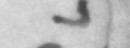

In [ ]:
show_sample(
    "syriac_2024_0006525.jpg",
    "Gutter/fragment 130×48. GT ܏ܢـ is abbreviation mark + Arabic tatweel, not a text line. Drop.",
)

## 2. Length 1–7 (64% CER) — not mostly “hard Syriac”

52 val lines, only **165 characters**, so this bin barely moves overall CER (~1% of all errors). It looks catastrophic because the labels are folio numbers, a lone `܀`, `܏`+letter abbreviations, and **sideways / too-tall crops**.

25 val crops have height > width. After resize to line height 48, some have fewer CTC timesteps than GT characters (`63×245` → 12 px wide for 7 letters).

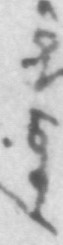

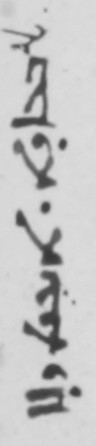

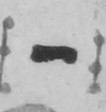

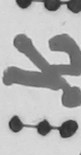

In [14]:

show_sample(
    "syriac_2024_0014825.jpg",
    "GT ܕܡܢ ܗܫܐ on a 63×245 vertical crop. Text is rotated 90°. CTC cannot align this.",
)
show_sample(
    "syriac_2025_0015332.jpg",
    "96×446 vertical crop of an 18-character line. GT even starts with a stray combining tilde ̰.",
)
show_sample(
    "syriac_2025_0015821.jpg",
    "GT is two abbreviation marks ܏܏. The crop is decorative separators, not letters.",
)
show_sample(
    "syriac_2025_0014928.jpg",
    "GT ܟܓ܏. Typical short 2025 abbreviation/number with U+070F, which has no ink of its own.",
)

## 3. Length 29–62 (50.5% CER) — this *is* `syriac_2024`

288 / 290 val lines in this bin are 2024. Mean GT length: **2024 = 42.4**, **2025 = 17.8**. 2024 crops are ~1210 px wide at ~26 px/character; 2025 is ~717 px at ~40 px/character. After the standard resize to height 48, 2024 has about **10 px/character vs 16** for 2025.

2024 also almost never uses the Syriac vowel points that 2025 uses (`ܿ` 556 times and `ܼ` 512 times in 2025; 3 and 0 in 2024). The two sources are different books with different GT conventions, mixed in one charset.

Predictions on 2024 long lines collapse: the model emits a much shorter string and skips whole words. Best 2024 long CER is still ~29%. **Zero exact matches** in this bin.

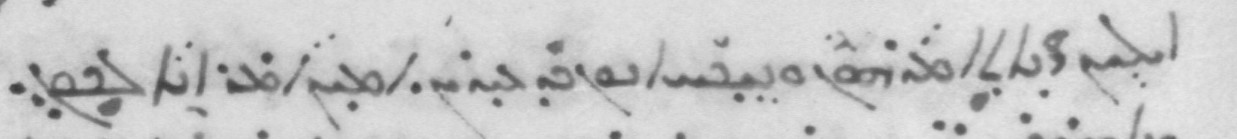

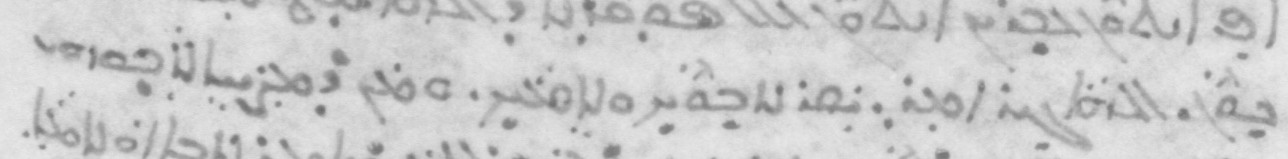

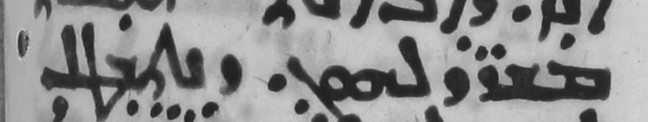

In [ ]:
show_sample(
    "syriac_2024_0014537.jpg",
    "Typical 2024 val line: full-width Serto, ASCII periods, combining dots. This length bin is 50% CER.",
)
show_sample(
    "syriac_2024_0014778.jpg",
    "Worst-ish 2024 long line (70% CER). PRED is much shorter than GT — the network is skipping.",
)
show_sample(
    "syriac_2025_0015459.jpg",
    "Typical 2025 val line (~18 characters, column width). 2025 overall is 17.5% CER.",
)

## 4. Same ink, two Unicode names — unify these

Both books already write the same marks. The GT does not. Calamari then learns two classes for one blob of ink.

| Ink on the page | Wrong encodings in GT | Count (pretrain) | Correct symbol |
|---|---|---|---|
| one-dot phrase stop (after a word) | ASCII `.` U+002E | 10,744 (both books) | **`܁` U+0701** (already 118× in 2025) |
| two stacked dots | ASCII `:` U+003A | 553 (both books) | **`܃` U+0703** (already 4×) |
| one dot *above a letter* (qushshaya) | `݁` U+0741 | 45 | **`̇` U+0307** (already 4,865×) |
| one dot *below a letter* (rukkakha) | `݂` U+0742 | 25 | **`̣` U+0323** (already 4,454×) |

**Do not merge** these — they are different inks, and 2025 uses them as East pointing:

| Ink | Keep | Why |
|---|---|---|
| slash / clause colon | `܆` U+0706 | diagonal, not a period; both books already agree |
| double slash | `܇` U+0707 | same |
| four-dot paragraph | `܀` U+0700 | same |
| seyame (two dots above) | `̈` U+0308 | both books already use this |
| East *rwaha* (dot above, vowel) | `ܿ` U+073F | 556× in 2025, **0** in 2024; not qushshaya |
| East *hbasa-esasa* (dot below, vowel) | `ܼ` U+073C | 512× in 2025; not rukkakha |

`src/preprocessing_data/syriac.py` `normalize_symbol_encoding` applies the table above (same policy as Armenian ASCII `.`/`.` → native marks). Re-run the cell below after the GT rewrite: GT should already show the **correct** column.

--- Unify: one-dot phrase stop  (`.` → ܁) ---
marks before: '.' U+002E  '̈' U+0308  '.' U+002E  '̣' U+0323
marks now:    '܁' U+0701  '̈' U+0308  '܁' U+0701  '̣' U+0323


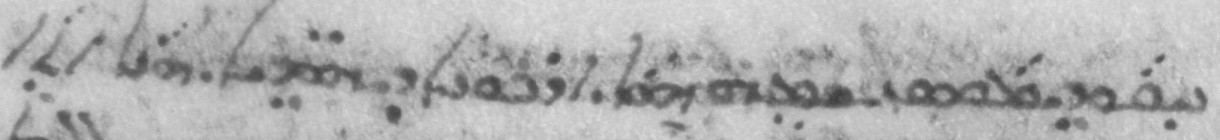

marks before: '̈' U+0308  '̈' U+0308  '.' U+002E
marks now:    '̈' U+0308  '̈' U+0308  '܁' U+0701


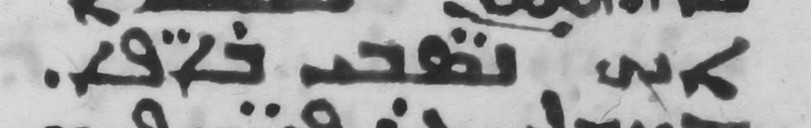

marks before: '̣' U+0323  '܁' U+0701  '̣' U+0323
marks now:    '̣' U+0323  '܁' U+0701  '̣' U+0323


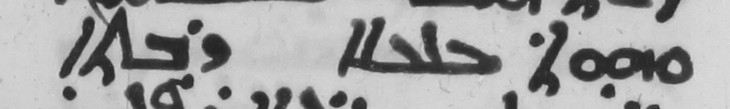

--- Do not unify with the above: slash clause mark ܆ (already shared) ---
marks before: '̈' U+0308  '܆' U+0706
marks now:    '̈' U+0308  '܆' U+0706


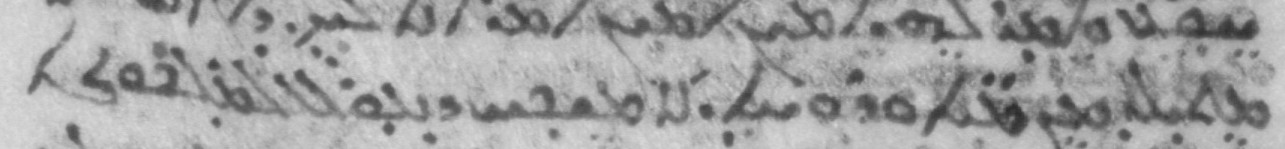

marks before: '܆' U+0706
marks now:    '܆' U+0706


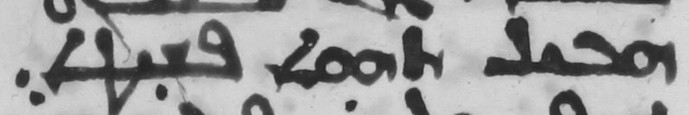

--- Unify: two stacked dots  (':' → ܃) ---
marks before: '.' U+002E  '̇' U+0307  '.' U+002E  '̣' U+0323  ':' U+003A
marks now:    '܁' U+0701  '̇' U+0307  '܁' U+0701  '̣' U+0323  '܃' U+0703


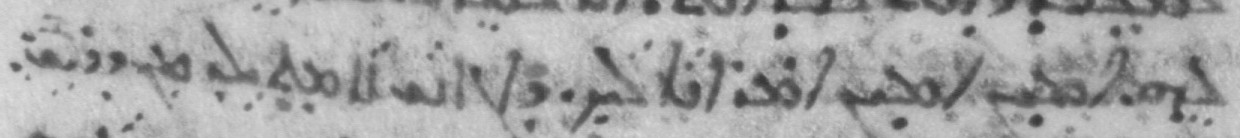

marks before: ':' U+003A
marks now:    '܃' U+0703


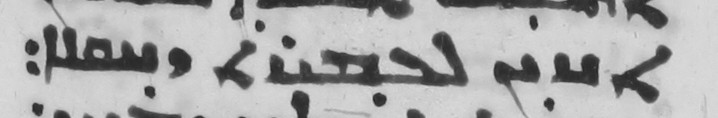

--- Unify: qushshaya  (݁ → ̇) ---
marks before: '.' U+002E  '݁' U+0741  '.' U+002E  '̇' U+0307  '.' U+002E
marks now:    '܁' U+0701  '̇' U+0307  '܁' U+0701  '̇' U+0307  '܁' U+0701


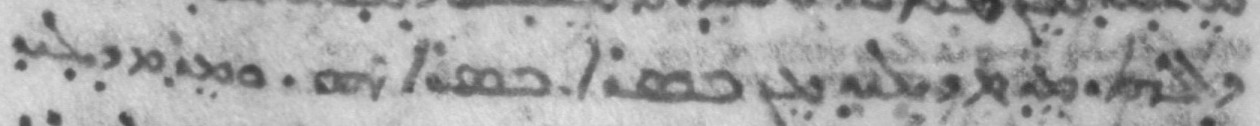

marks before: '݁' U+0741  '.' U+002E
marks now:    '̇' U+0307  '܁' U+0701


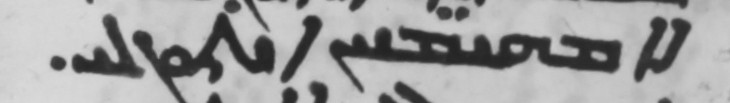

--- Unify: rukkakha  (݂ → ̣) ---
marks before: '̇' U+0307  '݂' U+0742  '̇' U+0307  '.' U+002E
marks now:    '̇' U+0307  '̣' U+0323  '̇' U+0307  '܁' U+0701


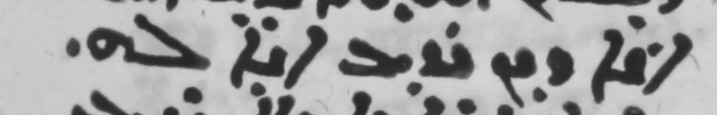

marks before: '.' U+002E  '̈' U+0308  '.' U+002E  '̣' U+0323
marks now:    '܁' U+0701  '̈' U+0308  '܁' U+0701  '̣' U+0323


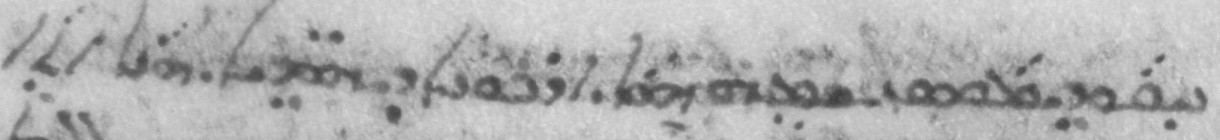

--- Do not unify: East vowels ܿ / ܼ vs qushshaya / rukkakha ---
marks before: '̈' U+0308  '܆' U+0706  'ܿ' U+073F
marks now:    '̈' U+0308  '܆' U+0706  'ܿ' U+073F


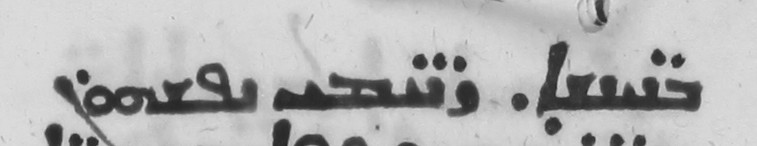

marks before: '̇' U+0307  '.' U+002E  '.' U+002E  '̣' U+0323  '.' U+002E
marks now:    '̇' U+0307  '܁' U+0701  '܁' U+0701  '̣' U+0323  '܁' U+0701


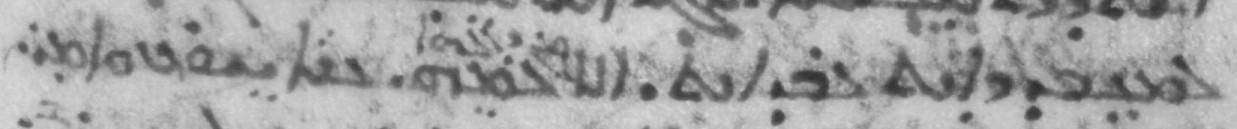

marks before: 'ܼ' U+073C  '܆' U+0706  'ܼ' U+073C
marks now:    'ܼ' U+073C  '܆' U+0706  'ܼ' U+073C


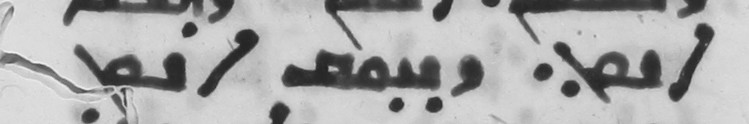

marks before: '.' U+002E  '̣' U+0323  '.' U+002E  '܆' U+0706  '̇' U+0307  '̣' U+0323
marks now:    '܁' U+0701  '̣' U+0323  '܁' U+0701  '܆' U+0706  '̇' U+0307  '̣' U+0323


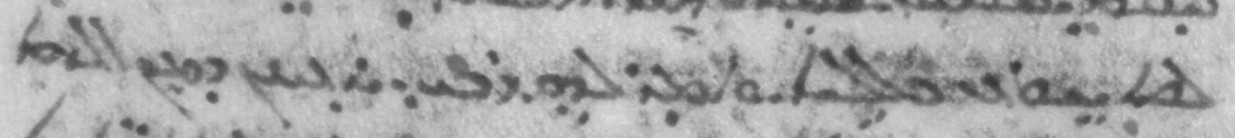

In [ ]:
MARKS = ".:,\u0741\u0742\u0701\u0703\u0706\u0707\u0700\u0307\u0323\u0308\u073f\u073c"

# GT as it was before unify — so this cell still shows the mismatch after the rewrite.
BEFORE = {
    "syriac_2024_0000002.jpg": "ܢܝܩܕܝܡܘܣ ܫܡܗ ܗܘܐ. ܐܪܟܘܢܐ ܕܝܗ̈ܘܕܝܐ. ܗܢܐ ܐܬ̣ܐ",
    "syriac_2025_0000048.jpg": "ܐܝܟ ܢܣ̈ܒܝ ܒܐ̈ܦܐ.",
    "syriac_2025_0000850.jpg": "ܘܗܘ̣ܬ܁ ܥܠܥܠܐ ܪܒܬ̣ܐ",
    "syriac_2024_0000011.jpg": "ܡܬܝܠܕ ܡܢ ܡ̈ܝܐ ܘܪܘܚܐ܆ ܠܐ ܡܫܟܚ ܕܢܥܘܠ ܠܡܠܟܘܬܐ",
    "syriac_2025_0000077.jpg": "ܗܟܝܠ ܬܗܘܐ ܦܫܝܛܐ܆",
    "syriac_2024_0000006.jpg": "ܠܗ. ܐܡܝܢ ܐܡܝܢ ܐܡ̇ܪ ܐܢܐ ܠܟ. ܕܐܢ ܐܢܫ ܠܐ ܡܬܝܠܕ ܡ̣ܢ ܕܪܝܫ:",
    "syriac_2025_0000118.jpg": "ܐܢܕܝܢ ܠܥܡܝܪܐ ܕܚܩܠܐ:",
    "syriac_2024_0000012.jpg": "ܕܐܠܗܐ. ܡܕ݁ܡ ܕܝܠܝܕ ܡܢ ܒܣܪܐ. ܒܣܪܐ ܗ̇ܘ. ܘܡܕܡ ܕܝܠܝܕ",
    "syriac_2025_0001156.jpg": "ܠܐ ܡܗܝܡܢܝܢ ܐܢܬ݁ܘܢ ܠܝ.",
    "syriac_2025_0001189.jpg": "ܐܢ̇ܐ ܕܝܢ ܝܕ݂ܥ ܐܢ̇ܐ ܠܗ.",
    "syriac_2025_0002822.jpg": "ܒ̈ܢܝܢܫܐ܆ ܪܚܿܡܝ ܢܦܫܗܘܢ",
    "syriac_2024_0000005.jpg": "ܠܡܥܒܕ ܕܐܢܬ ܥ̇ܒܕ ܐܢܬ. ܐܠܐ ܥܡܗ. ܥܢܐ ܝܫܘܥ ܘܐܡ̣ܪ.",
    "syriac_2025_0002835.jpg": "ܐܢܼܘܢ܆ ܕܚܘܩ ܐܢܼܘܢ",
    "syriac_2024_0000003.jpg": "ܠܘܬ ܝܫܘܥ ܒܠܠܝܐ. ܘܐܡ̣ܪ ܠܗ. ܪܒܝ܆ ܝ̇ܕܥܝܢܢ ܕܡ̣ܢ ܐܠܗܐ",
}


def dump_marks(text: str) -> str:
    found = [(c, f"U+{ord(c):04X}") for c in text if c in MARKS]
    if not found:
        return "(none of the punctuation/point marks)"
    return "  ".join(f"{c!r} {code}" for c, code in found)


def show_pair(image_name: str, problem: str) -> None:
    split, gt, path = lookup_gt(image_name)
    before = BEFORE[image_name]
    print(f"marks before: {dump_marks(before)}")
    print(f"marks now:    {dump_marks(gt)}")
    show_sample(image_name, problem)
    display(
        HTML(
            "<pre style='white-space:pre-wrap;font-size:14px'>"
            f"BEFORE: {escape(before)}\n"
            f"NOW:    {escape(gt)}"
            "</pre>"
        )
    )


print("--- Unify: one-dot phrase stop  (`.` → ܁) ---")
show_pair(
    "syriac_2024_0000002.jpg",
    "2024 used ASCII '.' (U+002E) for the one-dot stop after ܗܘܐ and ܝܗ̈ܘܕܝܐ. "
    "Correct: ܁ (U+0701).",
)
show_pair(
    "syriac_2025_0000048.jpg",
    "2025 used the same ASCII '.' for the same one-dot stop. Correct: ܁.",
)
show_pair(
    "syriac_2025_0000850.jpg",
    "Same one-dot stop, already encoded as ܁ (U+0701) on this 2025 line (after ܘܗܘ̣ܬ). "
    "This is the target encoding — BEFORE and NOW should match.",
)

print("--- Do not unify with the above: slash clause mark ܆ (already shared) ---")
show_pair(
    "syriac_2024_0000011.jpg",
    "Diagonal clause mark ܆ (U+0706), not a period. Both books already use ܆. Leave it.",
)
show_pair(
    "syriac_2025_0000077.jpg",
    "2025 ܆ — same ink as the 2024 line above. Already unified. Distinct from ܁.",
)

print("--- Unify: two stacked dots  (':' → ܃) ---")
show_pair(
    "syriac_2024_0000006.jpg",
    "2024 used ASCII ':' (U+003A) at the end. Correct: ܃ (U+0703).",
)
show_pair(
    "syriac_2025_0000118.jpg",
    "2025 used the same ASCII ':' for the same two stacked dots. Correct: ܃.",
)

print("--- Unify: qushshaya  (݁ → ̇) ---")
show_pair(
    "syriac_2024_0000012.jpg",
    "This 2024 line mixed both encodings of one-dot-above: ݁ on ܡܕ݁ܡ and ̇ on ܗ̇ܘ. "
    "Same ink. Correct: ̇ (U+0307) everywhere.",
)
show_pair(
    "syriac_2025_0001156.jpg",
    "2025 qushshaya as ݁ on ܐܢ݁ܬܘܢ. Correct: ̇.",
)

print("--- Unify: rukkakha  (݂ → ̣) ---")
show_pair(
    "syriac_2025_0001189.jpg",
    "2025 rukkakha as ݂ on ܝܕ݂ܥ. Same one-dot-below as ̣ elsewhere. Correct: ̣ (U+0323).",
)
show_pair(
    "syriac_2024_0000002.jpg",
    "2024 already uses ̣ on ܐܬ̣ܐ. That is the target encoding for rukkakha.",
)

print("--- Do not unify: East vowels ܿ / ܼ vs qushshaya / rukkakha ---")
show_pair(
    "syriac_2025_0002822.jpg",
    "2025 rwaha ܿ (U+073F) on ܪܚܿܡܝ. This is an East vowel, not qushshaya. Keep ܿ.",
)
show_pair(
    "syriac_2024_0000005.jpg",
    "2024 qushshaya ̇ on ܥ̇ܒܕ — one-dot-above as a consonant point, not ܿ. Keep ̇.",
)
show_pair(
    "syriac_2025_0002835.jpg",
    "2025 hbasa-esasa ܼ (U+073C) on ܐܢܼܘܢ. East vowel, not rukkakha. Keep ܼ.",
)
show_pair(
    "syriac_2024_0000003.jpg",
    "2024 rukkakha ̣ on ܐܡ̣ܪ / ܡ̣ܢ — consonant point, not ܼ. Keep ̣.",
)

## 6. Abbreviation mark `܏` (U+070F) and tall leftover crops

`܏` is a **format character**, not a letter. In the manuscript it is usually an **overline** over an abbreviated name (`܏ܢܝܩܘܕܝܡܘ` = Nicodemus). **476** GT rows contain it.

- **258** are otherwise normal long lines — the mark is just in the transcription.
- **201** are short GT (length ≤ 5): `܏ܠܛ`, `܏ܝ`, `܏ܡܙ`. CTC cannot see ink for `܏` itself.

**218 tall leftover crops** (`height > width`) were **not** rotated. The 120 we rotated were real sideways lines with enough letters. These 218 are short margin stacks (GT length 1–4). **125** of them also contain `܏`.

Arabic tatweel `ـ` was stripped from the 3 GT rows that had it (images kept). ZWNJ is still in 2 rows.

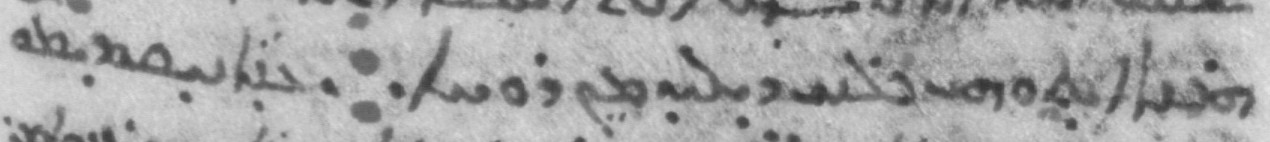

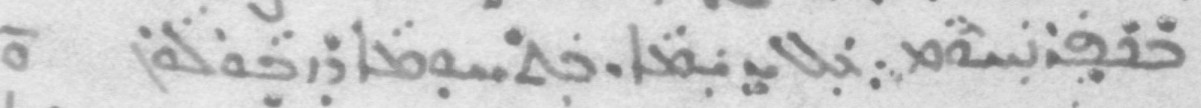

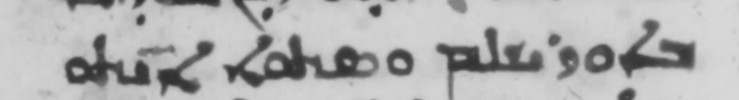

In [15]:
# Three normal long lines that contain ܏ (overline on an abbreviated name).
ABBREV_LONG_EXAMPLES = [
    ("syriac_2024_0000016.jpg", "Nicodemus abbreviated: ܏ܢܝܩܘܕܝܡܘ"),
    ("syriac_2024_0004465.jpg", "Short abbreviation at end of a real line: ܏ܘ"),
    ("syriac_2025_0012258.jpg", "2025 line with ܏ܐܝܬܘ"),
]
for name, note in ABBREV_LONG_EXAMPLES:
    show_crop_only(name, lookup_gt(name)[1], extra=note)


In [ ]:
SHEET_DIR = REPO / "src" / "experiments" / "syriac_abbrev_tall"
print("Long-line ܏ sample (12 of 258). The mark is in GT; the crop is a normal text line.")
display(IPyImage(filename=str(SHEET_DIR / "abbrev_long_sample.png")))
print("Short GT with ܏ (201 rows, length ≤ 5). Many are margin abbreviations, not full lines.")
display(IPyImage(filename=str(SHEET_DIR / "abbrev_short.png")))


In [ ]:
print("All 218 tall leftover crops (h > w), not rotated. Short margin stacks / ܏ labels.")
display(IPyImage(filename=str(SHEET_DIR / "tall_leftover.png")))


## 5. What to drop or normalize (same kind of list as Armenian)

1. **Drop folio / catalog rows from 2024** — anything that is only digits, `v`/`V`, `.`, `,`. That removes Latin and digits from the codec.
2. **Drop or rotate the tall crops** — `height > width`, especially val examples like `syriac_2024_0014825.jpg` and `syriac_2025_0015332.jpg`.
3. **Drop the `s` line** and the three Arabic-tatweel / ZWNJ rows.
4. **Symbol encoding is unified** (section 4): `.`→`܁`, `:`→`܃`, `݁`→`̇`, `݂`→`̣` in processed Syriac GT and combined manifests. Retrain so the charset drops the duplicate classes. Do **not** merge `ܿ`/`ܼ` into those dots.
5. Mixing 2024 and 2025 is correct once encodings and gutter crops match. Length-bin CER was a source proxy, not a reason to split by line length.

Items 1–3 are still GT junk. The checkpoint on disk was trained on the old mixed encodings.